This notebook is used to complete question 2 of the homework.

(i) First, we initialise the drift-diffusion model (DDM) as per the lecture slides.

(ii) We then hyperparameter tune values of drift, $v$, between 0.5 - 1.5 and record the mean differences of the two decision boundaries.

(iii) Finally, we then hyperparameter tune other factors to determine the impact on the mean differences.

# (i) Initialisation...

In [63]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [64]:
def ddm_trial(v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """
    Simulates one realization of the diffusion process given
    a set of parameters and a step size `dt`.

    Parameters:
    -----------
    v     : float
        The drift rate (rate of information uptake)
    a     : float
        The boundary separation (decision threshold).
    beta  : float in [0, 1]
        Relative starting point (prior option preferences)
    tau   : float
        Non-decision time (additive constant)
    dt    : float, optional (default: 1e-3 = 0.001)
        The step size for the Euler algorithm.
    scale : float, optional (default: 1.0)
        The scale (sqrt(var)) of the Wiener process. Not considered
        a parameter and typically fixed to either 1.0 or 0.1.
    max_time: float, optional (default: .10)
        The maximum number of seconds before forced termination.

    Returns:
    --------
    (x, c) - a tuple of response time (y - float) and a 
        binary decision (c - int) 
    """

    # initialisation...
    evidence_acc = a * beta
    time_acc = 0.


    # simulation...
    while (time_acc < max_time):
        # with each timestamp, we update the evidence accumulation by dX_t, 
        #  which we use the Euler-Maruyama method as described in slide17...
        
        # Z_t ~ N(0,1)
        Z_t = np.random.randn()

        evidence_acc += v*dt + scale*np.sqrt(dt)*Z_t  
        time_acc += dt


        # checking if either boundary was reached...
        if (evidence_acc >= a):
            return (time_acc + tau, 1) 
        
        if (evidence_acc <= 0):
            return (time_acc + tau, 0)
        

    # return the closest boundary if we exceed the time limit...
    midpt = a / 2
    bin_decision = 1 if evidence_acc > midpt else 0

    return (max_time + tau, bin_decision)
    

def ddm(num_sims, v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    data = np.zeros((num_sims, 2))
    for n in range(num_sims):
        data[n, :] = ddm_trial(v, a, beta, tau, dt, scale, max_time)
    return data


def visualize_diffusion_model(data, figsize=(8, 6)):
    f, ax = plt.subplots(1, 1, figsize=figsize)
    sns.histplot(data[:, 0][data[:, 1] == 1], color='maroon', alpha=0.7, ax=ax, label='Correct responses')
    sns.histplot(data[:, 0][data[:, 1] == 0], color='gray', ax=ax, label='Incorrect responses')
    sns.despine(ax=ax)
    ax.set_xlabel('Response time (s)', fontsize=18)
    ax.set_ylabel('')
    ax.legend(fontsize=18)
    ax.set_yticks([])
    return f

# (ii) hyperparamter tuning on $v$ and analysis on mean difference...

first , we ensure that ches both boundaries relatively equally and not just the upper boundary...

In [65]:
# testing to make sure that the process reaches both boundaries relatively equally...
N = 2000

v = 1.5
a = 0.5
beta = 0.5
tau = 0.7

ddm_data = ddm(N, v, a, beta, tau)

upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]

print("total UB:", len(upperbound))
print("total LB:", len(lowerbound))
print("mean UB:", np.mean(upperbound))
print("mean LB:", np.mean(lowerbound))
print("STDEV UB:", np.std(upperbound))
print("STDEV LB:", np.std(lowerbound))

total UB: 1385
total LB: 615
mean UB: 0.7708671480144403
mean LB: 0.769450406504065
STDEV UB: 0.05590716618839095
STDEV LB: 0.05456387675171388


In [66]:
v_range = np.linspace(0.5, 1.5, 25)
N = 2000


# other parameters are fixed such that the process doesn't just reach the upper boundary...
a = 0.5
beta = 0.5
tau = 0.7


upperbound_mean = np.zeros(len(v_range))
lowerbound_mean = np.zeros(len(v_range))
diff_mean = np.zeros(len(v_range))


for i, v in enumerate(v_range):
    ddm_data = ddm(N, v, a, beta, tau)


    # separating trial outcomes into respective boundaries... 
    #   (we just want the response time so only grab that column)
    upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
    lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]


    # computing respective means...
    upperbound_mean[i] = np.mean(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_mean[i] = np.mean(lowerbound) if len(lowerbound) > 0 else np.nan

    diff_mean[i] = upperbound_mean[i] - lowerbound_mean[i]

    


In [67]:
diff_mean

array([ 1.90837601e-03, -1.36355806e-03,  9.75499678e-04, -2.05483456e-03,
        2.42124506e-03,  4.80449249e-05, -2.93826746e-03, -1.02996516e-03,
       -1.03871845e-03,  2.15730051e-03, -7.34592530e-04, -2.32360156e-04,
        5.02693603e-03, -1.46645236e-03, -3.10900881e-03,  5.71839416e-04,
       -1.82112325e-03, -3.12089385e-03, -1.28049735e-03,  4.33659298e-03,
        4.40797721e-04, -1.93750434e-03, -1.09494830e-03,  3.82751938e-05,
       -5.62105717e-04])

interpretation:

The constant terms were $a = 0.5, \beta = 0.5, \tau = 0.7, N = 2000$.
From our results, we observe that the difference between the mean response times for the upper and lower boundaries were consistently quite small, around values of 0.015 - 0.02, which was consistent across all 25 different drift values tested. 
Our difference equation was $\mathrm{upperbound\_mean}_i - \mathrm{lowerbound\_mean}_i$, thus indicating that consistently, the upperbound mean was a bit greater than the lowerbound mean. 
This is counterintuitive since one may expect that the drift value may have a strong impact on the difference in timing between the correct and error responses. 
However, the data suggests that the overall impact of the drift value is limited since changing drift value does not shown any patterns in how the difference of means changes.


In [68]:
# f = visualize_diffusion_model(ddm_data)

# (iii) hyperparameter tuning on all variables and analysis on means and stdevs...

first, hyperparameter tuning on v (adding stdev)...

In [69]:
v_range = np.linspace(0.5, 1.5, 25)
N = 2000


# other parameters are fixed such that the process doesn't just reach the upper boundary...
a = 0.5
beta = 0.5
tau = 0.7


upperbound_mean = np.zeros(len(v_range))
lowerbound_mean = np.zeros(len(v_range))
diff_mean = np.zeros(len(v_range))
upperbound_stdev = np.zeros(len(v_range))
lowerbound_stdev = np.zeros(len(v_range))



for i, v in enumerate(v_range):
    ddm_data = ddm(N, v, a, beta, tau)


    # separating trial outcomes into respective boundaries... 
    #   (we just want the response time so only grab that column)
    upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
    lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]


    # computing respective means...
    upperbound_mean[i] = np.mean(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_mean[i] = np.mean(lowerbound) if len(lowerbound) > 0 else np.nan

    diff_mean[i] = upperbound_mean[i] - lowerbound_mean[i]

    upperbound_stdev[i] = np.std(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_stdev[i] = np.std(lowerbound) if len(lowerbound) > 0 else np.nan


In [70]:
print("mean UB:\n", upperbound_mean)
print()
print("mean LB:\n", lowerbound_mean)
print()
print("mean difference:\n", diff_mean)
print()
print("STDEV UB:\n", upperbound_stdev)
print()
print("STDEV LB:\n", lowerbound_stdev)

mean UB:
 [0.77094425 0.77233909 0.77228405 0.77169417 0.77200686 0.77116097
 0.77054691 0.77076603 0.77097277 0.77331549 0.77079473 0.76890071
 0.77138235 0.7719707  0.76971803 0.77043618 0.77029538 0.76882111
 0.76913024 0.76977239 0.77047099 0.76946662 0.77076957 0.76757531
 0.76817031]

mean LB:
 [0.77149765 0.77175386 0.77174321 0.77164625 0.77179472 0.77205368
 0.77165361 0.77173717 0.77448477 0.7707588  0.76999064 0.76793522
 0.77161995 0.76804613 0.77311471 0.7692213  0.76861571 0.77353313
 0.77206928 0.7719197  0.76636107 0.77012701 0.7678346  0.76823787
 0.76956869]

mean difference:
 [-5.53401711e-04  5.85220971e-04  5.40837510e-04  4.79166667e-05
  2.12137297e-04 -8.92715423e-04 -1.10669615e-03 -9.71143155e-04
 -3.51199930e-03  2.55669015e-03  8.04086723e-04  9.65492181e-04
 -2.37593150e-04  3.92457170e-03 -3.39667967e-03  1.21487841e-03
  1.67967033e-03 -4.71202475e-03 -2.93903759e-03 -2.14730891e-03
  4.10991735e-03 -6.60391359e-04  2.93497707e-03 -6.62559404e-04
 -1.3983

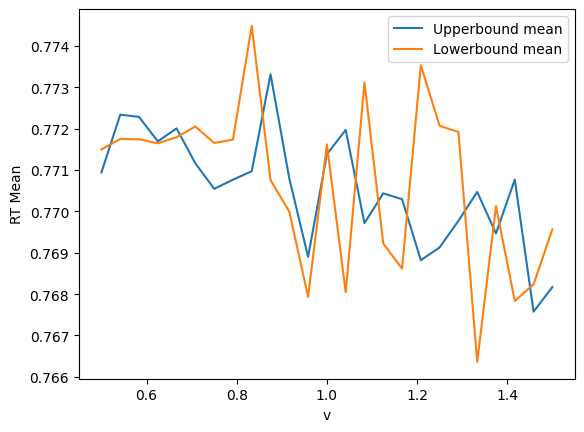

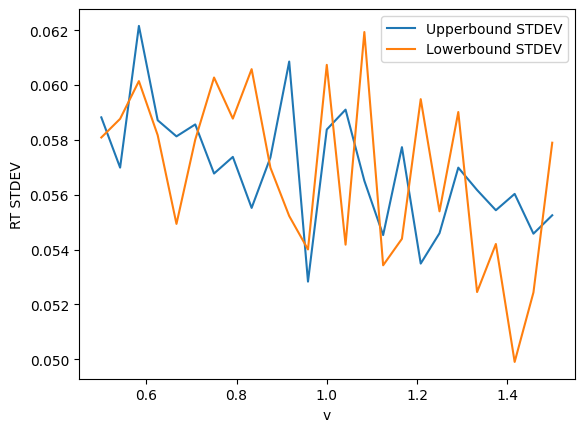

In [71]:
plt.plot(v_range, upperbound_mean, label="Upperbound mean")
plt.plot(v_range, lowerbound_mean, label="Lowerbound mean")
plt.xlabel("v")
plt.ylabel("RT Mean")
plt.legend()
plt.show()

plt.plot(v_range, upperbound_stdev, label="Upperbound STDEV")
plt.plot(v_range, lowerbound_stdev, label="Lowerbound STDEV")
plt.xlabel("v")
plt.ylabel("RT STDEV")
plt.legend()
plt.show()

now hyperparameter tuning on a...


In [72]:
# testing to make sure that the process reaches both boundaries relatively equally...
N = 2000

v = 0.5
a = 0.5
beta = 0.5
tau = 0.7

ddm_data = ddm(N, v, a, beta, tau)

upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]

print("total UB:", len(upperbound))
print("total LB:", len(lowerbound))
print("mean UB:", np.mean(upperbound))
print("mean LB:", np.mean(lowerbound))
print("STDEV UB:", np.std(upperbound))
print("STDEV LB:", np.std(lowerbound))

total UB: 1118
total LB: 882
mean UB: 0.7711475849731664
mean LB: 0.7712891156462586
STDEV UB: 0.05896210729807667
STDEV LB: 0.055036076351107674


In [73]:
a_range = np.linspace(0.3, 1.5, 25)
N = 2000


# other parameters are fixed such that the process doesn't just reach the upper boundary...
v = 0.5
beta = 0.5
tau = 0.7


upperbound_mean = np.zeros(len(a_range))
lowerbound_mean = np.zeros(len(a_range))
diff_mean = np.zeros(len(a_range))
upperbound_stdev = np.zeros(len(a_range))
lowerbound_stdev = np.zeros(len(a_range))



for i, a in enumerate(a_range):
    ddm_data = ddm(N, v, a, beta, tau)


    # separating trial outcomes into respective boundaries... 
    #   (we just want the response time so only grab that column)
    upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
    lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]


    # computing respective means...
    upperbound_mean[i] = np.mean(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_mean[i] = np.mean(lowerbound) if len(lowerbound) > 0 else np.nan

    diff_mean[i] = upperbound_mean[i] - lowerbound_mean[i]

    upperbound_stdev[i] = np.std(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_stdev[i] = np.std(lowerbound) if len(lowerbound) > 0 else np.nan


In [74]:
print("mean UB:\n", upperbound_mean)
print()
print("mean LB:\n", lowerbound_mean)
print()
print("mean difference:\n", diff_mean)
print()
print("STDEV UB:\n", upperbound_stdev)
print()
print("STDEV LB:\n", lowerbound_stdev)

mean UB:
 [0.72806938 0.73693994 0.74644152 0.75893088 0.77205203 0.78632056
 0.80041275 0.81559284 0.83137789 0.85531718 0.87123152 0.88772535
 0.9076686  0.92705854 0.97244749 1.00915185 1.01481712 1.03418536
 1.09011313 1.09296892 1.13040763 1.17983994 1.18166715 1.23672329
 1.26726061]

mean LB:
 [0.72761806 0.73792639 0.74732999 0.76124809 0.77153233 0.78566549
 0.80200124 0.81326029 0.83886929 0.85777913 0.87686346 0.89287581
 0.9161962  0.93333506 0.96793923 0.99462414 1.01468951 1.04406983
 1.0751875  1.11816446 1.15664103 1.16898944 1.18623718 1.24108742
 1.25389905]

mean difference:
 [ 0.00045132 -0.00098645 -0.00088847 -0.00231721  0.0005197   0.00065506
 -0.00158849  0.00233255 -0.0074914  -0.00246195 -0.00563194 -0.00515046
 -0.00852761 -0.00627653  0.00450827  0.01452771  0.00012761 -0.00988447
  0.01492563 -0.02519555 -0.0262334   0.0108505  -0.00457003 -0.00436413
  0.01336156]

STDEV UB:
 [0.0222202  0.0290723  0.03772504 0.04852573 0.05754463 0.06884227
 0.08044546 0

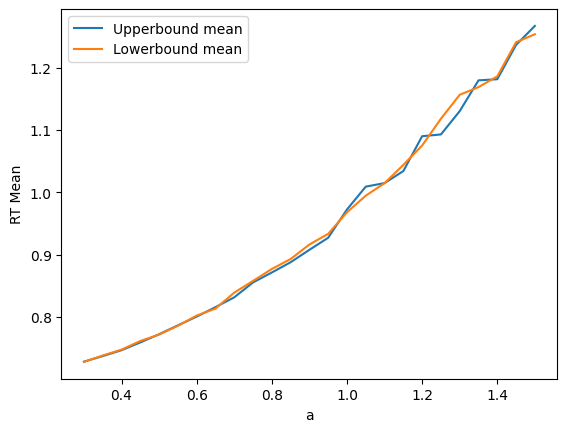

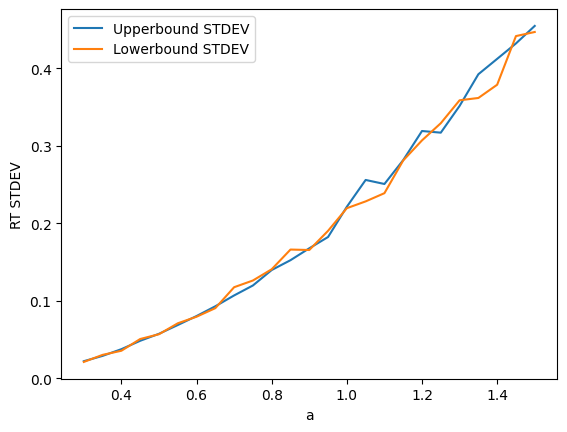

In [75]:
plt.plot(a_range, upperbound_mean, label="Upperbound mean")
plt.plot(a_range, lowerbound_mean, label="Lowerbound mean")
plt.xlabel("a")
plt.ylabel("RT Mean")
plt.legend()
plt.show()

plt.plot(a_range, upperbound_stdev, label="Upperbound STDEV")
plt.plot(a_range, lowerbound_stdev, label="Lowerbound STDEV")
plt.xlabel("a")
plt.ylabel("RT STDEV")
plt.legend()
plt.show()

now hyperparameter tuning on beta...


In [76]:
beta_range = np.linspace(0.2, 0.8, 25)
N = 2000


# other parameters are fixed such that the process doesn't just reach the upper boundary...
v = 0.5
a = 0.5
tau = 0.7


upperbound_mean = np.zeros(len(beta_range))
lowerbound_mean = np.zeros(len(beta_range))
diff_mean = np.zeros(len(beta_range))
upperbound_stdev = np.zeros(len(beta_range))
lowerbound_stdev = np.zeros(len(beta_range))



for i, beta in enumerate(beta_range):
    ddm_data = ddm(N, v, a, beta, tau)


    # separating trial outcomes into respective boundaries... 
    #   (we just want the response time so only grab that column)
    upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
    lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]


    # computing respective means...
    upperbound_mean[i] = np.mean(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_mean[i] = np.mean(lowerbound) if len(lowerbound) > 0 else np.nan

    diff_mean[i] = upperbound_mean[i] - lowerbound_mean[i]

    upperbound_stdev[i] = np.std(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_stdev[i] = np.std(lowerbound) if len(lowerbound) > 0 else np.nan


In [77]:
print("mean UB:\n", upperbound_mean)
print()
print("mean LB:\n", lowerbound_mean)
print()
print("mean difference:\n", diff_mean)
print()
print("STDEV UB:\n", upperbound_stdev)
print()
print("STDEV LB:\n", lowerbound_stdev)

mean UB:
 [0.79073954 0.78903808 0.78660033 0.78940089 0.78888462 0.78669693
 0.78415783 0.78241075 0.77841441 0.77986561 0.77451401 0.77551298
 0.77432686 0.76872947 0.76868714 0.76441972 0.76160309 0.75643787
 0.7587891  0.75084148 0.75060109 0.74422444 0.74388705 0.74368278
 0.7381426 ]

mean LB:
 [0.73668657 0.74226934 0.74459842 0.74790594 0.75139968 0.75228407
 0.75535844 0.75955701 0.76508445 0.76741802 0.76226632 0.77096376
 0.77312327 0.77120166 0.77614891 0.77955627 0.78188652 0.78080723
 0.78433663 0.78184683 0.78264218 0.78919551 0.78894226 0.78856477
 0.79917614]

mean difference:
 [ 0.05405298  0.04676874  0.04200191  0.04149495  0.03748494  0.03441286
  0.02879938  0.02285374  0.01332995  0.0124476   0.01224769  0.00454922
  0.00120358 -0.00247219 -0.00746177 -0.01513655 -0.02028344 -0.02436935
 -0.02554754 -0.03100535 -0.0320411  -0.04497107 -0.04505522 -0.04488199
 -0.06103354]

STDEV UB:
 [0.05907946 0.05564891 0.06180407 0.06039501 0.06416446 0.06635228
 0.06133026 0

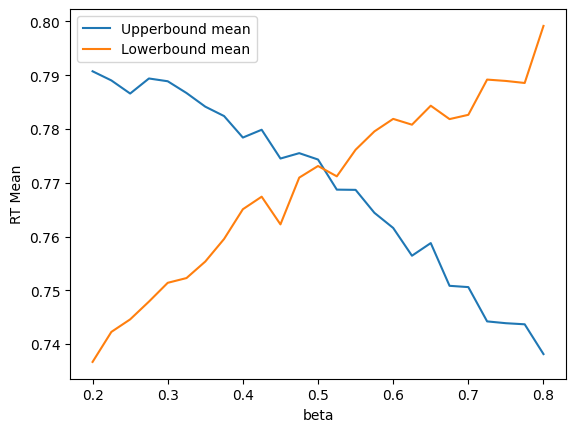

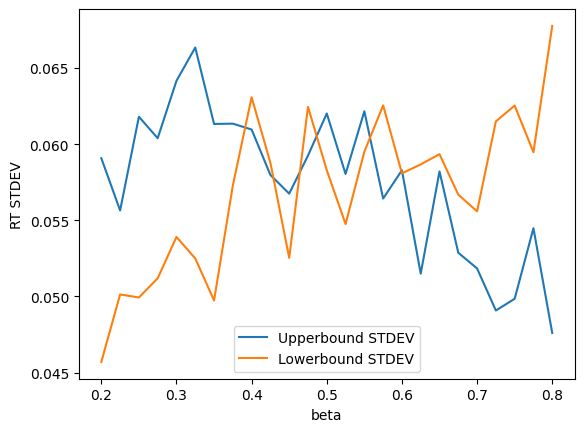

In [78]:
plt.plot(beta_range, upperbound_mean, label="Upperbound mean")
plt.plot(beta_range, lowerbound_mean, label="Lowerbound mean")
plt.xlabel("beta")
plt.ylabel("RT Mean")
plt.legend()
plt.show()

plt.plot(beta_range, upperbound_stdev, label="Upperbound STDEV")
plt.plot(beta_range, lowerbound_stdev, label="Lowerbound STDEV")
plt.xlabel("beta")
plt.ylabel("RT STDEV")
plt.legend()
plt.show()

now hyperparameter tuning on tau...


In [79]:
tau_range = np.linspace(0.2, 0.8, 25)
N = 2000


# other parameters are fixed such that the process doesn't just reach the upper boundary...
v = 0.5
a = 0.5
beta = 0.5


upperbound_mean = np.zeros(len(tau_range))
lowerbound_mean = np.zeros(len(tau_range))
diff_mean = np.zeros(len(tau_range))
upperbound_stdev = np.zeros(len(tau_range))
lowerbound_stdev = np.zeros(len(tau_range))



for i, tau in enumerate(tau_range):
    ddm_data = ddm(N, v, a, beta, tau)


    # separating trial outcomes into respective boundaries... 
    #   (we just want the response time so only grab that column)
    upperbound = ddm_data[ddm_data[:, 1] == 1, 0]
    lowerbound = ddm_data[ddm_data[:, 1] == 0, 0]


    # computing respective means...
    upperbound_mean[i] = np.mean(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_mean[i] = np.mean(lowerbound) if len(lowerbound) > 0 else np.nan

    diff_mean[i] = upperbound_mean[i] - lowerbound_mean[i]

    upperbound_stdev[i] = np.std(upperbound) if len(upperbound) > 0 else np.nan
    lowerbound_stdev[i] = np.std(lowerbound) if len(lowerbound) > 0 else np.nan


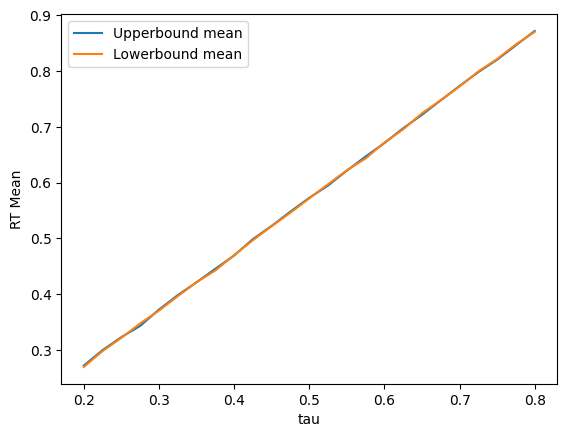

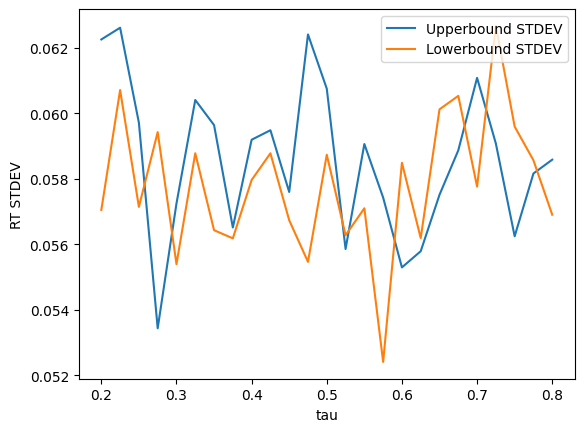

In [80]:
plt.plot(tau_range, upperbound_mean, label="Upperbound mean")
plt.plot(tau_range, lowerbound_mean, label="Lowerbound mean")
plt.xlabel("tau")
plt.ylabel("RT Mean")
plt.legend()
plt.show()

plt.plot(tau_range, upperbound_stdev, label="Upperbound STDEV")
plt.plot(tau_range, lowerbound_stdev, label="Lowerbound STDEV")
plt.xlabel("tau")
plt.ylabel("RT STDEV")
plt.legend()
plt.show()